# **Gradient Boosting**

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree


import warnings
warnings.filterwarnings('ignore')


In [48]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:,0]**2 + 0.05 * np.random.randn(100)

df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

print(df.shape)
df.head(5)


(100, 2)


,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


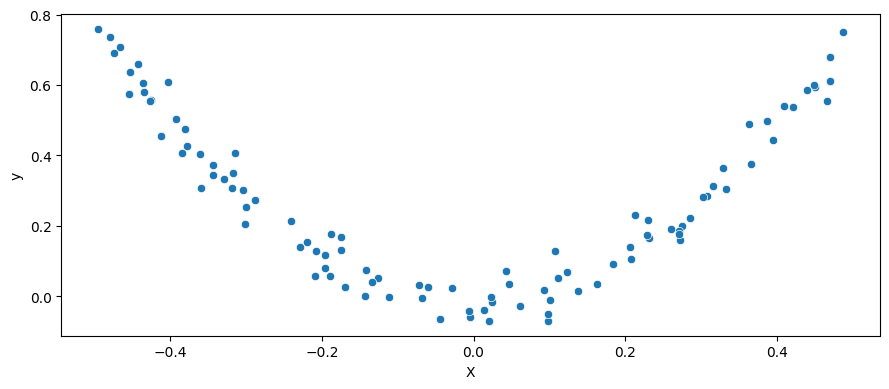

In [49]:
plt.figure(figsize=(9,4))
sns.scatterplot(x=df['X'], y=df['y'])
plt.tight_layout()
plt.show()

In [50]:
df['pred1'] = df['y'].mean()
df['res1'] = df['y'] - df['pred1']      # res1 = residual 1 (first resudual of the first model)

df.head(5)

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


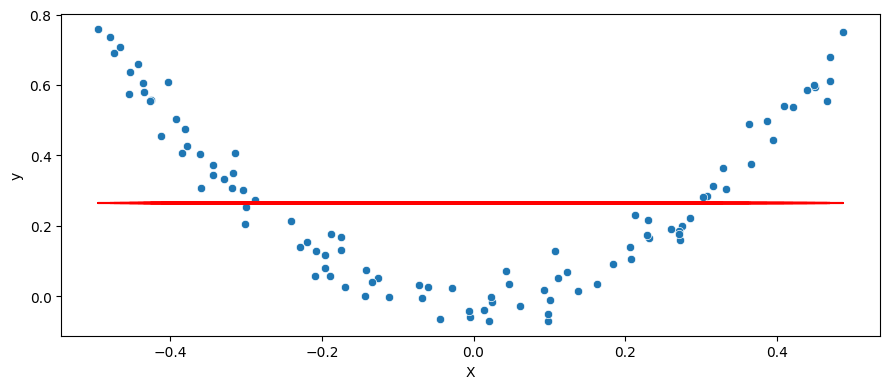

In [51]:
plt.figure(figsize=(9,4))
sns.scatterplot(x=df['X'], y=df['y'])
plt.plot(df['X'], df['pred1'], color='red')
plt.tight_layout()
plt.show()

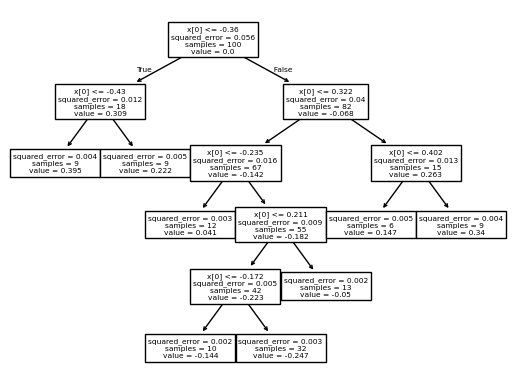

In [ ]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
# keep in mind while using gradient boost max_leaf must be btwn 8 to 32

tree1.fit(df['X'].values.reshape(100,1), df['res1'].values)

plot_tree(tree1);
plt.show()

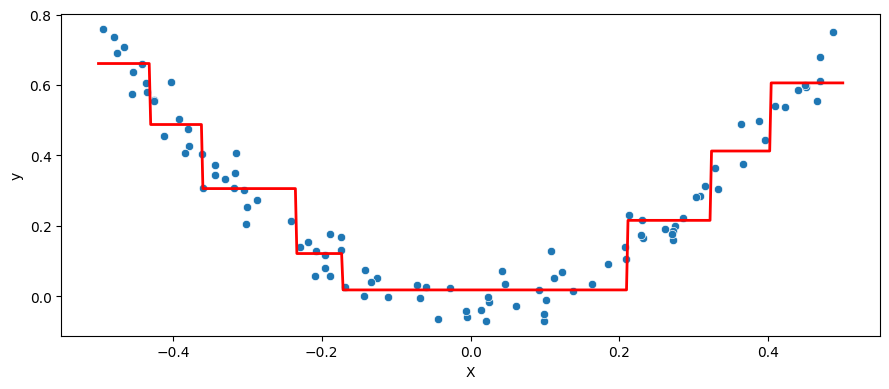

In [ ]:
# making test data
X_test = np.linspace(-0.5, 0.5, 500)

y_pred = 0.265458 + tree1.predict(X_test.reshape(500,1))        # 0.265458 is the mean of the first model


plt.figure(figsize=(9,4))
sns.scatterplot(x=df['X'], y=df['y'])
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.tight_layout()
plt.show()

In [54]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))
df['res2'] = df['y'] + df['pred2']

df.head(6)

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.069892
1,0.450714,0.594480,0.265458,0.329021,0.605884,1.200363
2,0.231994,0.166052,0.265458,-0.099407,0.215784,0.381835
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.051859
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.649950
5,-0.344005,0.372875,0.265458,0.107417,0.305964,0.678839


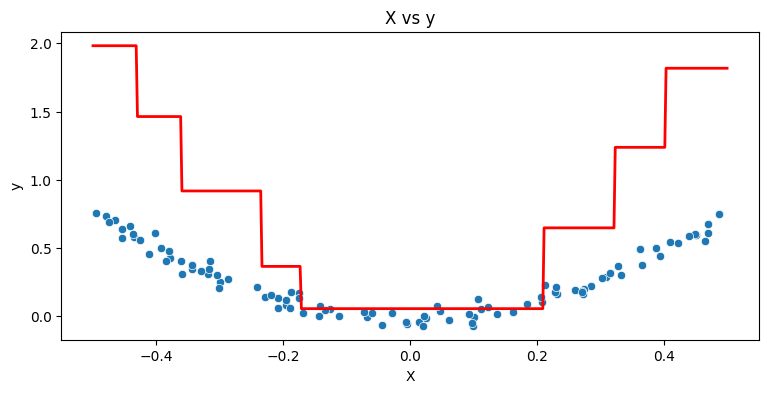

In [58]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1),df['res2'].values)
y_pred = 0.265458 + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1,tree2])


plt.figure(figsize=(9,4))
sns.scatterplot(x=df['X'], y=df['y'])
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.title('X vs y')
plt.show()

In [59]:
def gradient_boost(X,y,number,lr,count=1,regs=[],foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)


5


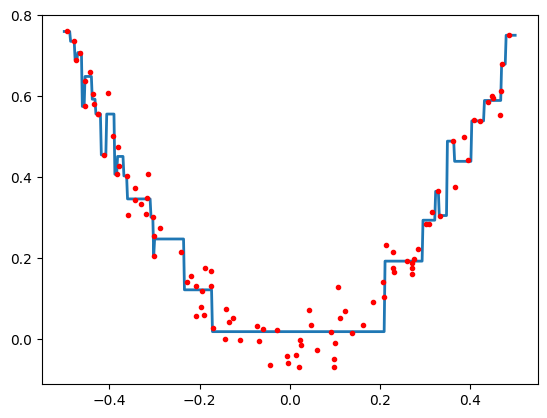

4


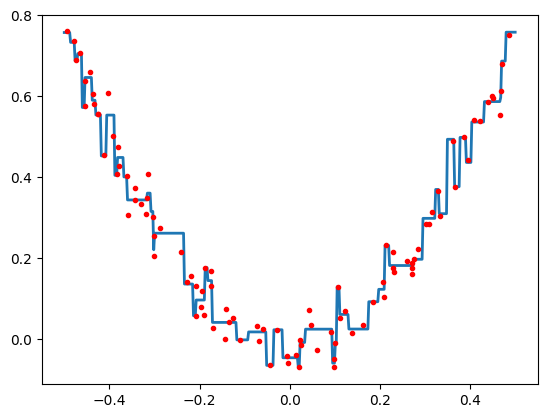

3


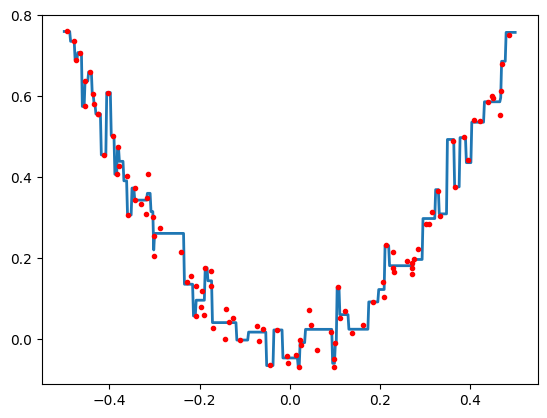

2


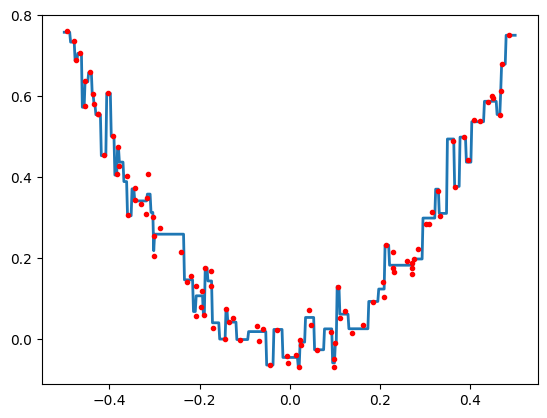

1


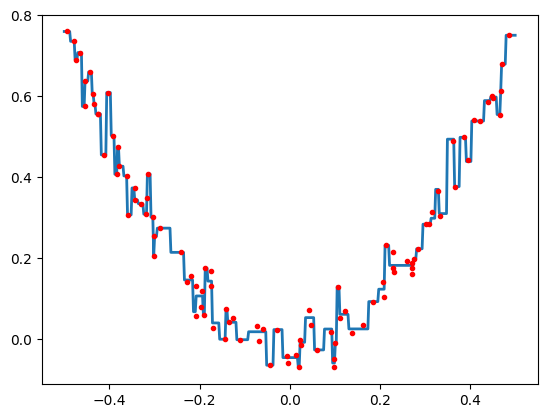

In [ ]:
np.random.seed(42) 

X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

gradient_boost(X,y,5,lr=1)